<a href="https://colab.research.google.com/github/RamcharanChandragiri/NATURAL-LANGUAGE-PROCESSING/blob/main/Lab_10_3_tSNF_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARIES

Import libraries for:

• loading embeddings

• handling matrices

• visualization

• t-SNE reduction

In [2]:
import sys
if 'gensim' not in sys.modules:
  !pip install gensim

import gensim.downloader as api          # Load pre-trained embeddings
import numpy as np                      # Matrix & numerical operations
import matplotlib.pyplot as plt         # Visualization
from sklearn.manifold import TSNE       # Dimensionality reduction

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.1 MB/s eta 0:00:00


LOAD EMBEDDING MODELS

• load pre-trained embeddings

• print vocabulary size

• display one example vector

In [11]:
# Load pre-trained Word2Vec (Google News 300-dimensional vectors)
model = api.load("word2vec-google-news-300")

# Print vocabulary size
print("Vocabulary size:", len(model))

# Display one example vector
example_word = "computer"
print("Vector for 'computer':")
print(model[example_word])

Vocabulary size: 3000000
Vector for 'computer':
[ 1.07421875e-01 -2.01171875e-01  1.23046875e-01  2.11914062e-01
 -9.13085938e-02  2.16796875e-01 -1.31835938e-01  8.30078125e-02
  2.02148438e-01  4.78515625e-02  3.66210938e-02 -2.45361328e-02
  2.39257812e-02 -1.60156250e-01 -2.61230469e-02  9.71679688e-02
 -6.34765625e-02  1.84570312e-01  1.70898438e-01 -1.63085938e-01
 -1.09375000e-01  1.49414062e-01 -4.65393066e-04  9.61914062e-02
  1.68945312e-01  2.60925293e-03  8.93554688e-02  6.49414062e-02
  3.56445312e-02 -6.93359375e-02 -1.46484375e-01 -1.21093750e-01
 -2.27539062e-01  2.45361328e-02 -1.24511719e-01 -3.18359375e-01
 -2.20703125e-01  1.30859375e-01  3.66210938e-02 -3.63769531e-02
 -1.13281250e-01  1.95312500e-01  9.76562500e-02  1.26953125e-01
  6.59179688e-02  6.93359375e-02  1.02539062e-02  1.75781250e-01
 -1.68945312e-01  1.21307373e-03 -2.98828125e-01 -1.15234375e-01
  5.66406250e-02 -1.77734375e-01 -2.08984375e-01  1.76757812e-01
  2.38037109e-02 -2.57812500e-01 -4.467773

SELECT WORD LIST


• choose 30–50 meaningful words

• store them in a list

• extract corresponding vectors

In [6]:
words = [
    # Animals
    "dog", "cat", "lion", "tiger", "wolf", "elephant", "horse",

    # Cities
    "Paris", "London", "Berlin", "Tokyo", "Beijing", "New_York", "Rome",

    # Technology
    "computer", "laptop", "keyboard", "mouse", "internet", "software", "hardware",

    # Fruits
    "apple", "banana", "orange", "grape", "mango", "pineapple", "peach",

    # Vehicles
    "car", "bus", "train", "airplane", "bicycle", "motorcycle"
]

# Extract vectors
vectors = np.array([model[word] for word in words])

APPLY t-SNE


• run t-SNE to reduce vectors from (e.g., 100/300 dims) → 2
dimensions

• store resulting coordinates

In [7]:
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
reduced_vectors = tsne.fit_transform(vectors)

PLOT VISUALISATION

• create scatter plot

• annotate each point with word label

• highlight visible clusters

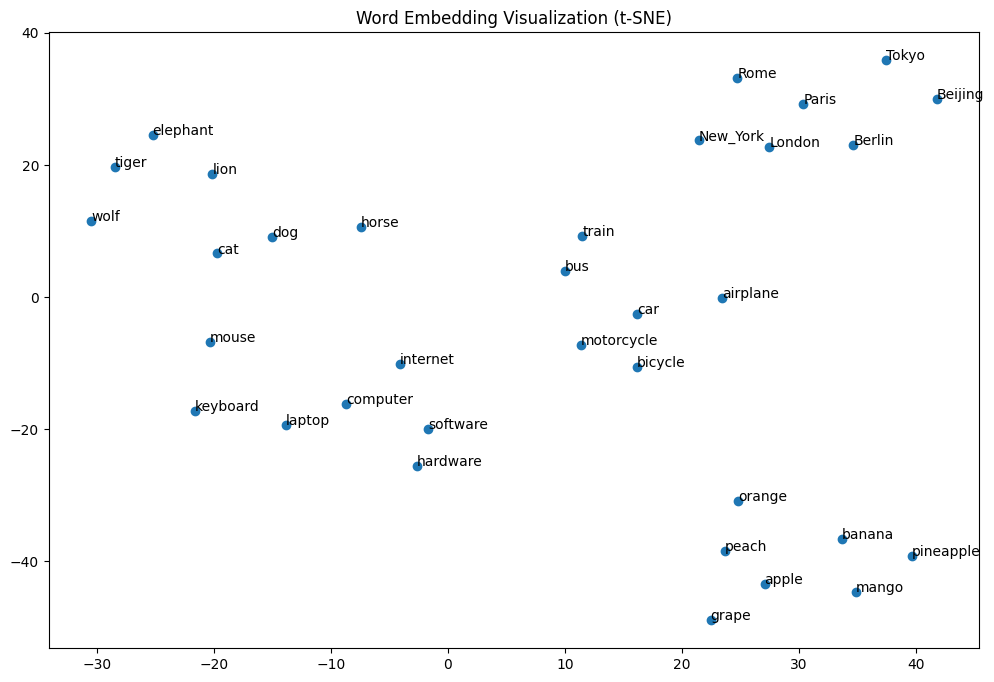

In [8]:
plt.figure(figsize=(12, 8))

x = reduced_vectors[:, 0]
y = reduced_vectors[:, 1]

plt.scatter(x, y)

# Annotate each word
for i, word in enumerate(words):
    plt.annotate(word, (x[i], y[i]))

plt.title("Word Embedding Visualization (t-SNE)")
plt.show()

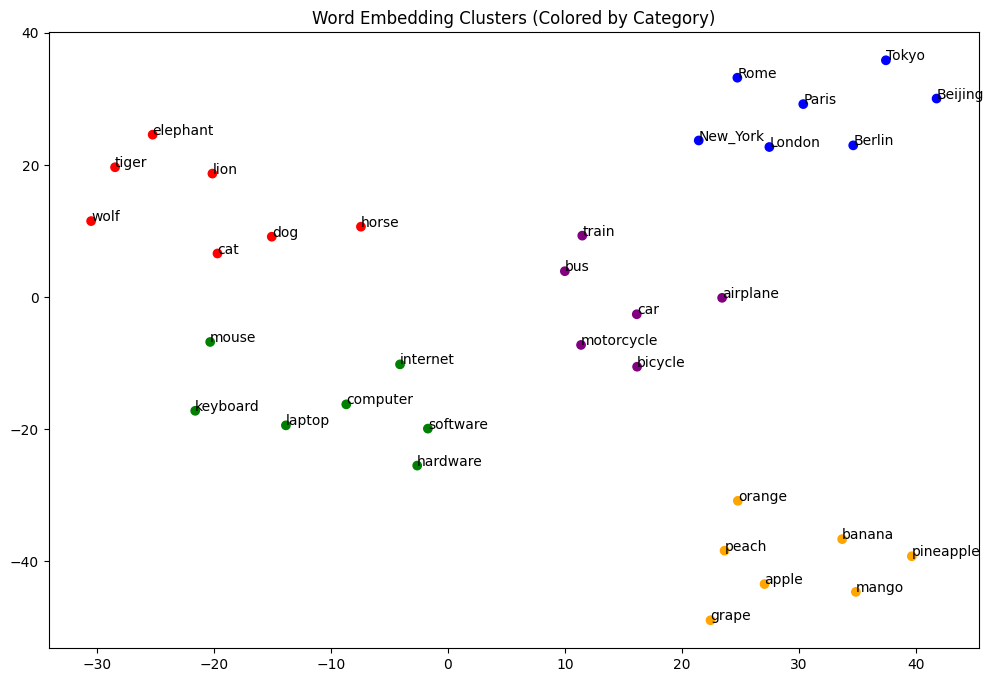

In [9]:
#COLOR BY CATEGORY
colors = (
    ["red"] * 7 +        # Animals
    ["blue"] * 7 +       # Cities
    ["green"] * 7 +      # Technology
    ["orange"] * 7 +     # Fruits
    ["purple"] * 6       # Vehicles
)

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c=colors)

for i, word in enumerate(words):
    plt.annotate(word, (x[i], y[i]))

plt.title("Word Embedding Clusters (Colored by Category)")
plt.show()